In [88]:

import os
os.environ["TORCH_ONNX_FORCE_OLD_EXPORTER"] = "1"
from onnx2pytorch import ConvertModel
from torch import nn
import torch.nn.functional as F
import onnx
import idx2numpy, numpy as np, torch
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import onnxruntime as ort
import matplotlib.pyplot as plt

In [89]:
model_path = "D:\\automated-object-control\\lab-for-block2\\nn_model.onnx"
data_idx_path = "D:\\automated-object-control\\lab-for-block2\\trainingDatas.idx"
label_idx_path = "D:\\automated-object-control\\lab-for-block2\\trainingLabels.idx"
onnx_model = onnx.load(model_path)
model = ConvertModel(onnx_model, experimental=True)


C:\Users\Baoyan Si\miniconda3\envs\automated-object-control\lib\site-packages\onnx2pytorch\convert\model.py:147: UserWarning: Using experimental implementation that allows 'batch_size > 1'.Batchnorm layers could potentially produce false outputs.
  warnings.warn(


In [90]:
X_idx = idx2numpy.convert_from_file(data_idx_path) #expect shape (N,4) or (N,1,4)
Y_idx = idx2numpy.convert_from_file(label_idx_path) #expect shape (N,)

print("X shape:", X_idx.shape, "| dtype:", X_idx.dtype)
print("Y shape:", Y_idx.shape, "| dtype:", Y_idx.dtype)

# 2) make contiguous writable copies with desired dtypes
X = torch.tensor(np.array(X_idx, dtype=np.float32, copy=True))
Y = torch.tensor(np.array(Y_idx, dtype=np.int64,  copy=True))

print("X:", X.shape, X.dtype, " | Y:", Y.shape, Y.dtype)

train_dataset = TensorDataset(X,Y)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)

X shape: (8006, 4) | dtype: >f4
Y shape: (8006,) | dtype: >i4
X: torch.Size([8006, 4]) torch.float32  | Y: torch.Size([8006]) torch.int64


In [91]:
#baseline eva
model.eval()
criterion = nn.CrossEntropyLoss()

with torch.no_grad():
    logits = model(X.float())
    baseline_loss = criterion(logits, Y)
    pred = logits.argmax(1)
    baseline_acc = (pred == Y).float().mean().item()

print(f" Baseline accuracy: {baseline_acc:.4f}")

 Baseline accuracy: 0.9494


In [92]:
criterion = nn.CrossEntropyLoss()
model.eval()
with torch.no_grad():
    logits = model(X[:256].float())
    ce = criterion(logits, Y[:256].long())
    pred = logits.argmax(1)
    acc = (pred == Y[:256]).float().mean().item()
print("CE(loss) first 256:", ce.item(), " | acc:", round(acc,4))

CE(loss) first 256: 0.2351202815771103  | acc: 0.9102


In [93]:
model.train()
criterion = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)

def robustness_property_loss(model, x, y, eps=0.01, steps=3, alpha=None):
    if alpha is None: alpha = eps/2
    x_adv = x.detach().clone().requires_grad_(True)
    for _ in range(steps):
        logits = model(x_adv)
        fy = logits.gather(1, y.view(-1,1))
        margins = logits - fy
        margins.scatter_(1, y.view(-1,1), float('-inf'))
        worst = margins.max(1).values.mean()
        grad, = torch.autograd.grad(worst, x_adv)
        with torch.no_grad():
            x_adv += alpha * torch.sign(grad)
            x_adv = torch.max(torch.min(x_adv, x + eps), x - eps)  # L∞ projection
        x_adv.requires_grad_(True)
    logits = model(x_adv)
    fy = logits.gather(1, y.view(-1,1))
    margins = logits - fy
    margins.scatter_(1, y.view(-1,1), float('-inf'))
    return F.relu(margins.max(1).values).mean()

In [95]:
lambda_start, lambda_end = 0.1, 3.0
eps_start,    eps_end    = 0.003, 0.02
epochs = 10

loss_hist, acc_hist = [], []

for epoch in range(epochs):
    t = epoch / max(1, epochs-1)
    lam = lambda_start + (lambda_end - lambda_start)*t
    eps = eps_start + (eps_end - eps_start)*t
    epoch_loss = 0.0
    epoch_correct = 0
    epoch_total = 0

    for x, y in train_loader:        # ensure x has shape [B, 4] with correct scaling
        x, y = x.float(), y.long()
        logits = model(x)
        data_loss = criterion(logits, y)
        prop_loss = robustness_property_loss(model, x, y, eps=eps, steps=3)
        loss = data_loss + lam * prop_loss

        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        pred = logits.argmax(1)           # [B]
        epoch_correct += (pred == y).sum().item()
        epoch_total  += y.size(0)
        epoch_loss   += loss.item() * y.size(0)


        avg_loss = epoch_loss / epoch_total
        acc = epoch_correct / epoch_total
        loss_hist.append(avg_loss)
        acc_hist.append(acc)

    print(f"Epoch {epoch+1}/{epochs} | Loss={avg_loss:.4f} | Acc={acc:.4f} | λ={lam:.2f}, ε={eps:.3f}")

Epoch 1/10 | Loss=0.1811 | Acc=0.9497 | λ=0.10, ε=0.003
Epoch 2/10 | Loss=0.2142 | Acc=0.9558 | λ=0.42, ε=0.005
Epoch 3/10 | Loss=0.2427 | Acc=0.9583 | λ=0.74, ε=0.007
Epoch 4/10 | Loss=0.2708 | Acc=0.9601 | λ=1.07, ε=0.009
Epoch 5/10 | Loss=0.2949 | Acc=0.9612 | λ=1.39, ε=0.011
Epoch 6/10 | Loss=0.3184 | Acc=0.9613 | λ=1.71, ε=0.012
Epoch 7/10 | Loss=0.3388 | Acc=0.9624 | λ=2.03, ε=0.014
Epoch 8/10 | Loss=0.3581 | Acc=0.9630 | λ=2.36, ε=0.016
Epoch 9/10 | Loss=0.3809 | Acc=0.9624 | λ=2.68, ε=0.018
Epoch 10/10 | Loss=0.3974 | Acc=0.9632 | λ=3.00, ε=0.020


In [99]:
model.eval()
with torch.no_grad():
    logits = model(X)
    pred = logits.argmax(1)
    acc = (pred == Y).float().mean().item()
print("train accuracy:", round(acc, 4))

train accuracy: 0.9622


In [98]:
# quick random 80/20 split check (repeat a couple of times)
perm = torch.randperm(len(X))
cut = int(0.8*len(X))
idx_tr, idx_te = perm[:cut], perm[cut:]
with torch.no_grad():
    acc_te = (model(X[idx_te]).argmax(1) == Y[idx_te]).float().mean().item()
print("held-out acc:", round(acc_te,4))

held-out acc: 0.9644


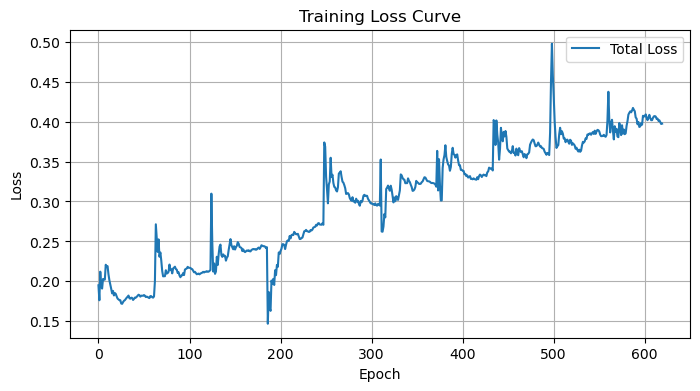

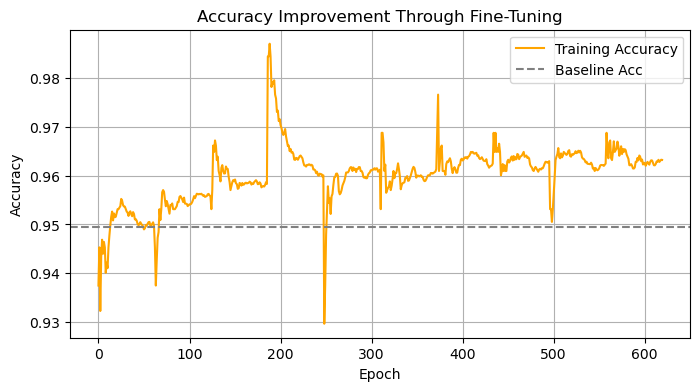

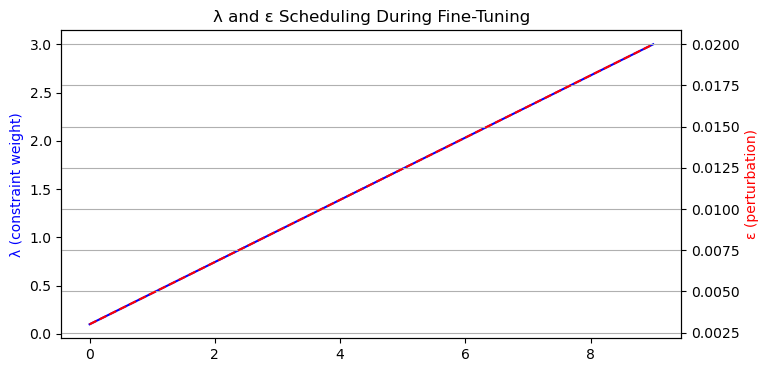

Fine-tuned accuracy: 0.9622
Improvement: 0.0127


In [102]:
plt.figure(figsize=(8,4))
plt.plot(loss_hist, label="Total Loss")
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(acc_hist, label="Training Accuracy", color='orange')
plt.axhline(baseline_acc, color='gray', linestyle='--', label='Baseline Acc')
plt.title("Accuracy Improvement Through Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# Plot λ and ε schedules
lambda_values = np.linspace(lambda_start, lambda_end, epochs)
eps_values = np.linspace(eps_start, eps_end, epochs)

fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(range(epochs), lambda_values, 'b-', label='λ schedule')
ax1.set_ylabel('λ (constraint weight)', color='b')
ax2 = ax1.twinx()
ax2.plot(range(epochs), eps_values, 'r--', label='ε schedule')
ax2.set_ylabel('ε (perturbation)', color='r')
plt.title("λ and ε Scheduling During Fine-Tuning")
plt.grid(True)
plt.show()

# ============================================================
# 6️⃣ Post-Training Evaluation
# ============================================================
model.eval()
with torch.no_grad():
    logits = model(X)
    final_acc = (logits.argmax(1) == Y).float().mean().item()

print(f"Fine-tuned accuracy: {final_acc:.4f}")
print(f"Improvement: {final_acc - baseline_acc:.4f}")

In [84]:
# save_path = Path("nn_model_finetuned.onnx")
# save_path.parent.mkdir(parents=True, exist_ok=True)
#
# model.eval()
# torch.onnx.export(
#     model,
#     X[:1].float(),              # example input
#     save_path.as_posix(),
#     input_names=["input"],
#     output_names=["logits"],
#     opset_version=18,           # ONNX opset to use
#     export_params=True,
#     do_constant_folding=True,
# )

In [101]:

# onnx_path = "nn_model_finetuned.onnx"

#Check that the ONNX file is structurally valid
# onnx.checker.check_model(onnx_path)
# print("Model structure verified")

#Inspect I/O names and shapes
# model = onnx.load(onnx_path)
# print("Inputs:", [i.name for i in model.graph.input])
# print("Outputs:", [o.name for o in model.graph.output])

#Run an inference test with ONNX Runtime
# sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
# example = np.random.randn(1, 4).astype(np.float32)
# onnx_out = sess.run(None, {"input": example})[0]
#
# print("ONNX output sample:", onnx_out)
# print("ONNX model runs successfully")